# Credit Default MLOps Workflow

This notebook covers:
- dataset loading and EDA
- train/test split and evaluation metric
- MLflow experiment tracking and FLAML AutoML
- model export for FastAPI inference
- monitoring on original vs changed test data

Recommended dataset: UCI `Default of Credit Card Clients` (`id=350`).

In [1]:
%pip install -q -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from evidently.metric_preset import ClassificationPreset, DataDriftPreset
from evidently.report import Report
from flaml import AutoML
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

In [3]:
RANDOM_STATE = 42
ARTIFACTS = Path('../artifacts')
REPORTS = Path('../reports')
MODELS = Path('../models')
for folder in [ARTIFACTS, REPORTS, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('credit-default-notebook')

<Experiment: artifact_location='/Users/yichunzhang/Desktop/0uchi_courses/2MLOps/MLOps/final/notebooks/../mlruns/946889961732434698', creation_time=1779832072286, experiment_id='946889961732434698', last_update_time=1779832072286, lifecycle_stage='active', name='credit-default-notebook', tags={}>

## 1. Load dataset

In [4]:
dataset = fetch_ucirepo(id=350)
X = dataset.data.features.copy()
column_mapping = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
}
X = X.rename(columns=column_mapping)
y = dataset.data.targets.squeeze().copy()

print(X.shape, y.shape)
display(X.head())
display(y.value_counts(normalize=True).rename('target_ratio'))

(30000, 23) (30000,)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


Y
0    0.7788
1    0.2212
Name: target_ratio, dtype: float64

## 2. EDA

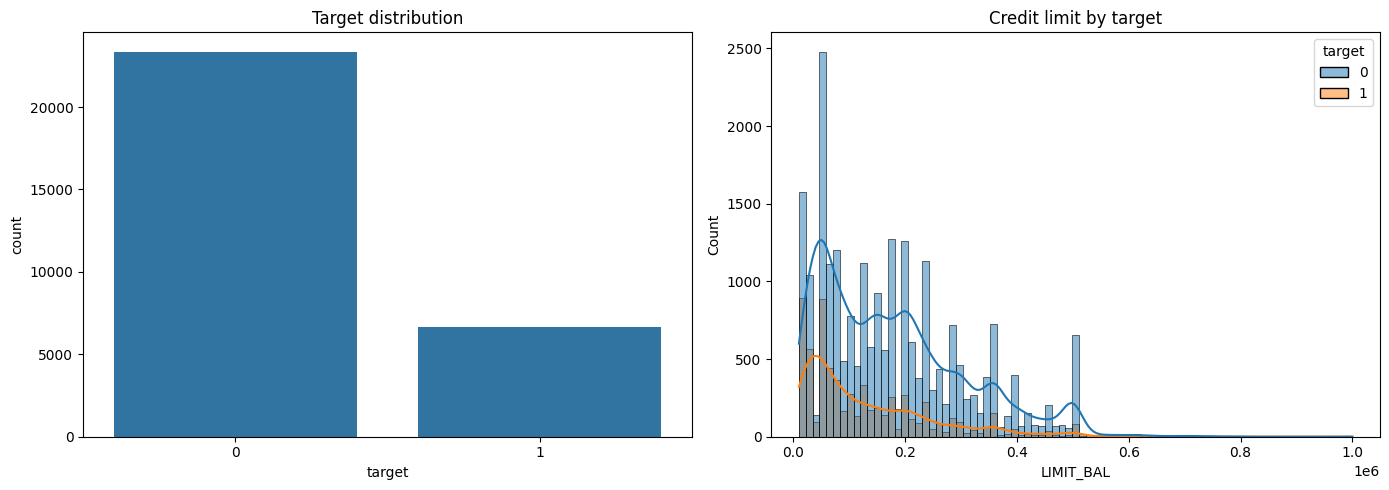

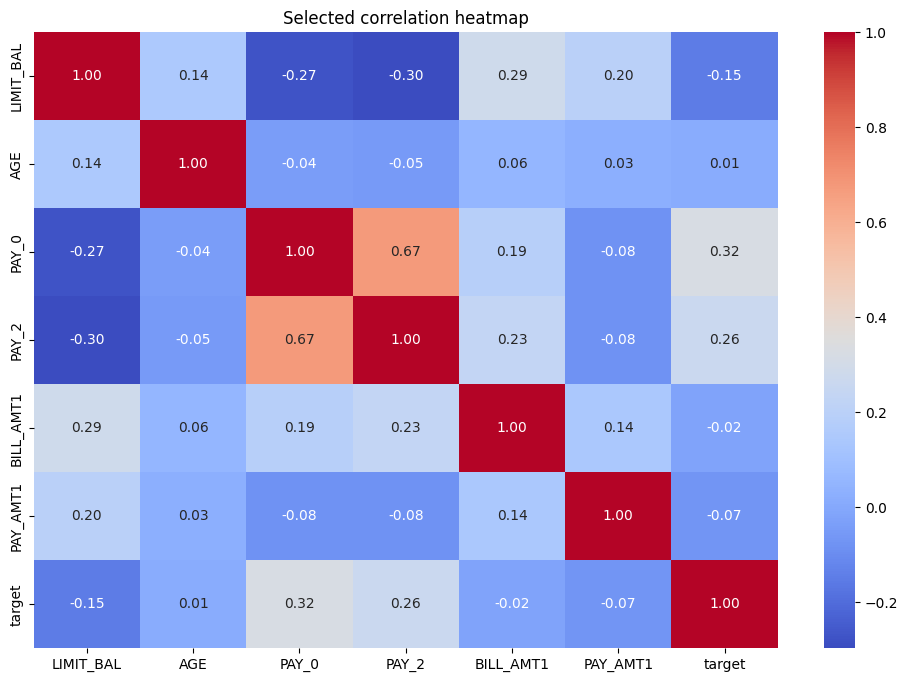

In [5]:
eda = X.copy()
eda['target'] = y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='target', data=eda, ax=axes[0])
axes[0].set_title('Target distribution')
sns.histplot(data=eda, x='LIMIT_BAL', hue='target', kde=True, ax=axes[1])
axes[1].set_title('Credit limit by target')
plt.tight_layout()

plt.figure(figsize=(12, 8))
corr_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'target']
sns.heatmap(eda[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Selected correlation heatmap')
plt.show()

## 3. Train / test split and metric

Primary metric: `ROC-AUC`.

Why:
- the target is binary and imbalanced
- ROC-AUC evaluates ranking quality across thresholds
- we still report `F1` and `accuracy` as secondary metrics

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('train:', X_train.shape, 'test:', X_test.shape)

train: (24000, 23) test: (6000, 23)


## 4. MLflow + AutoML

In [7]:
numeric_features = X.columns.tolist()
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

automl = AutoML()
automl_settings = {
    'time_budget': 120,
    'metric': 'roc_auc',
    'task': 'classification',
    'log_file_name': str(ARTIFACTS / 'flaml.log'),
    'seed': RANDOM_STATE,
}

with mlflow.start_run(run_name='flaml-credit-default'):
    automl.fit(X_train=X_train_processed, y_train=y_train, **automl_settings)
    best_model = automl.model.estimator
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', best_model),
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'roc_auc': roc_auc_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred),
    }
    mlflow.log_params({
        'dataset': 'UCI Default of Credit Card Clients',
        'automl_best_estimator': automl.best_estimator,
        'time_budget': automl_settings['time_budget'],
        'primary_metric': 'roc_auc',
    })
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(pipeline, artifact_path='model')
    joblib.dump(pipeline, MODELS / 'credit_default_pipeline.joblib')

metrics

[flaml.automl.logger: 05-26 16:49:59] {1728} INFO - task = classification


[flaml.automl.logger: 05-26 16:49:59] {1739} INFO - Evaluation method: holdout


[flaml.automl.logger: 05-26 16:49:59] {1838} INFO - Minimizing error metric: 1-roc_auc


[flaml.automl.logger: 05-26 16:49:59] {1955} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']


[flaml.automl.logger: 05-26 16:49:59] {2258} INFO - iteration 0, current learner lgbm


...

[flaml.automl.logger: 05-26 16:52:00] {2691} INFO - Best MLflow run id: 2bd88b58561740f591c39a52ce2f6cd6


[flaml.automl.logger: 05-26 16:52:04] {1985} INFO - fit succeeded


[flaml.automl.logger: 05-26 16:52:04] {1986} INFO - Time taken to find the best model: 52.66603994369507


2026/05/26 16:52:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


{'roc_auc': np.float64(0.7785784907155554),
 'f1': np.float64(0.470703125),
 'accuracy': 0.8193333333333334}

In [8]:
print('Best estimator from FLAML:', automl.best_estimator)
print(classification_report(y_test, y_pred))

Best estimator from FLAML: lgbm
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



## 5. Monitoring on original test data

In [9]:
reference_df = X_train.copy()
reference_df['target'] = y_train.values
reference_df['prediction'] = pipeline.predict(X_train)
reference_df['prediction_proba'] = pipeline.predict_proba(X_train)[:, 1]

current_df = X_test.copy()
current_df['target'] = y_test.values
current_df['prediction'] = y_pred
current_df['prediction_proba'] = y_prob

report = Report(metrics=[DataDriftPreset(), ClassificationPreset()])
report.run(reference_data=reference_df, current_data=current_df)
report.save_html(str(REPORTS / 'test_monitoring_report.html'))
print('Saved:', REPORTS / 'test_monitoring_report.html')

Saved: ../reports/test_monitoring_report.html


## 6. Create changed test data

In [10]:
X_test_changed = X_test.copy()

# Change at least two features to simulate drift.
X_test_changed['LIMIT_BAL'] = X_test_changed['LIMIT_BAL'] * 1.8
X_test_changed['PAY_0'] = X_test_changed['PAY_0'].sample(frac=1.0, random_state=RANDOM_STATE).values

changed_pred = pipeline.predict(X_test_changed)
changed_prob = pipeline.predict_proba(X_test_changed)[:, 1]

changed_metrics = {
    'roc_auc': roc_auc_score(y_test, changed_prob),
    'f1': f1_score(y_test, changed_pred),
    'accuracy': accuracy_score(y_test, changed_pred),
}
changed_metrics

{'roc_auc': np.float64(0.7010935691592629),
 'f1': np.float64(0.21250691754288878),
 'accuracy': 0.7628333333333334}

## 7. Monitoring on changed test data

In [11]:
changed_df = X_test_changed.copy()
changed_df['target'] = y_test.values
changed_df['prediction'] = changed_pred
changed_df['prediction_proba'] = changed_prob

changed_report = Report(metrics=[DataDriftPreset(), ClassificationPreset()])
changed_report.run(reference_data=reference_df, current_data=changed_df)
changed_report.save_html(str(REPORTS / 'changed_test_monitoring_report.html'))
print('Saved:', REPORTS / 'changed_test_monitoring_report.html')

Saved: ../reports/changed_test_monitoring_report.html
